In [1]:
import random, warnings, collections
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew, entropy as scipy_entropy
from scipy.fft import fft2, fftshift
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT   = Path(r"C:\Users\Windows\Documents\CASIA2")
AU_DIR = ROOT / 'Au'
TP_DIR = ROOT / 'Tp'
EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

In [2]:
from PIL import Image

def load_rgb(path, maxdim=512):
    try:
        img = Image.open(path).convert('RGB')
    except Exception:
        return None
    w, h = img.size
    if max(w, h) > maxdim:
        s = maxdim / max(w, h)
        img = img.resize((max(1, int(w*s)), max(1, int(h*s))), Image.LANCZOS)
    return np.array(img, dtype=np.uint8)

def load_gray(path, maxdim=512):
    rgb = load_rgb(path, maxdim)
    return None if rgb is None else cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def get_tp_label(path):
    parts = path.stem.split('_')
    try:
        return 1 if parts[1] == 'S' else 2
    except Exception:
        return 2

In [3]:
def akaze_features(path, min_dist=15, ratio=0.93):
    img = load_gray(path)
    if img is None:
        return np.zeros(15, dtype=np.float32)

    kps, descs = cv2.AKAZE_create(threshold=0.0002).detectAndCompute(img, None)
    if descs is None or len(kps) < 8:
        return np.zeros(15, dtype=np.float32)

    candidates = []
    for trip in cv2.BFMatcher(cv2.NORM_HAMMING).knnMatch(descs, descs, k=4):
        ns = [m for m in trip if m.queryIdx != m.trainIdx]
        if len(ns) < 2: continue
        m, n = ns[0], ns[1]
        if m.distance <= ratio * n.distance:
            p1 = np.array(kps[m.queryIdx].pt, dtype=np.float32)
            p2 = np.array(kps[m.trainIdx].pt, dtype=np.float32)
            d  = p2 - p1
            if np.linalg.norm(d) > min_dist:
                candidates.append((p1, p2, d, m.distance))

    if len(candidates) < 5:
        return np.zeros(15, dtype=np.float32)

    disps = np.array([c[2] for c in candidates], dtype=np.float32)
    quant = np.round(disps / 4.0).astype(np.int16)
    keys, counts = np.unique(quant, axis=0, return_counts=True)

    total_cands = len(candidates)
    best_count  = int(counts.max())
    displacement_dominance = float(best_count / total_cands)

    n_directions = float(len(keys))
    count_probs  = counts.astype(np.float32) / counts.sum()
    from scipy.stats import entropy as _entropy
    disp_entropy = float(_entropy(count_probs))

    # ── Displacement-to-texture-period alignment ──────────────────────────────
    h_img, w_img = img.shape
    size_ac = 128
    img_small = cv2.resize(img.astype(np.float32), (size_ac, size_ac))
    img_small -= img_small.mean()
    denom = np.sum(img_small**2) + 1e-8
    F = np.fft.fft2(img_small)
    ac = np.real(np.fft.ifft2(F * np.conj(F))) / denom
    ac = np.fft.fftshift(ac)
    cy_ac, cx_ac = size_ac // 2, size_ac // 2
    ac[cy_ac, cx_ac] = 0.0
    ac_h_slice = ac[cy_ac, cx_ac+3:]
    ac_v_slice = ac[cy_ac+3:, cx_ac]
    tex_period_h = float(np.argmax(ac_h_slice) + 3) * (w_img / size_ac)
    tex_period_v = float(np.argmax(ac_v_slice) + 3) * (h_img / size_ac)
    tex_period = min(tex_period_h, tex_period_v)
    ac_peak_strength = float(max(ac_h_slice.max(), ac_v_slice.max()))

    best_disp = keys[np.argmax(counts)].astype(np.float32) * 4.0
    dominant_disp_len = float(np.linalg.norm(best_disp))
    if tex_period > 0 and dominant_disp_len > 0:
        ratio_dt = dominant_disp_len / (tex_period + 1e-8)
        disp_tex_alignment = float(abs(ratio_dt - round(ratio_dt)))
    else:
        disp_tex_alignment = 1.0

    mask    = np.all(quant == keys[np.argmax(counts)], axis=1)
    inliers = [c for c, k in zip(candidates, mask) if k]

    n_in = len(inliers)
    if n_in == 0:
        return np.zeros(15, dtype=np.float32)

    in_d  = np.array([c[2] for c in inliers], dtype=np.float32)
    lens  = np.linalg.norm(in_d, axis=1)
    angs  = np.arctan2(in_d[:, 1], in_d[:, 0])
    dists = np.array([c[3] for c in inliers], dtype=np.float32)
    pts   = np.array([c[0] for c in inliers], dtype=np.float32)
    in_ratio    = n_in / max(total_cands, 1)
    compactness = float(np.mean(np.linalg.norm(pts - pts.mean(axis=0), axis=1)))
    consistency = float(1.0 / (1.0 + lens.std()))
    mean_dd     = float(dists.mean())
    cm_score    = float((1 - np.exp(-n_in / 10.0)) * (0.5 + 0.5 * in_ratio))

    # ── BUG A FIX: inlier spatial compactness (replaces kp_bimodal) ──────────
    # For genuine copy-move: all inlier SOURCE points come from ONE compact object.
    # → Their std is small relative to image diagonal → low inlier_scatter_ratio.
    # For texture/ornamental aliasing: inlier sources are spread across the image.
    # → Their std is large relative to image diagonal → high inlier_scatter_ratio.
    # This uses only INLIER points (dominant displacement cluster), not all keypoints,
    # so subject+background blur, reflections, stripes do NOT trigger it.
    img_diag = float(np.sqrt(h_img**2 + w_img**2)) + 1e-8
    pts_std  = float(np.std(pts))   # std of inlier source positions
    inlier_scatter_ratio = pts_std / img_diag
    # Low → compact region (copy-move object). High → scattered (texture aliasing).

    cm_hard_flag = float(
        n_in >= 12 and
        in_ratio >= 0.25 and
        consistency >= 0.08 and
        mean_dd <= 80 and
        displacement_dominance >= 0.20 and
        disp_tex_alignment >= 0.25 and      # displacement ≠ texture period
        inlier_scatter_ratio <= 0.35        # inliers come from compact region
    )

    return np.array([cm_score, float(n_in), float(in_ratio), float(lens.mean()),
                     float(lens.std()), float(angs.std()), compactness, consistency,
                     mean_dd, cm_hard_flag, displacement_dominance, disp_entropy,
                     inlier_scatter_ratio, float(n_directions), disp_tex_alignment],
                    dtype=np.float32)

In [4]:
SRM_KERNELS = [
    np.array([[0,0,0],[0,-1,1],[0,0,0]], dtype=np.float32),
    np.array([[0,0,0],[0,-1,0],[0,1,0]], dtype=np.float32),
    np.array([[0,0,0],[0,-1,0],[0,0,1]], dtype=np.float32),
    np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32) / 4,
]

def srm_features(path):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(28, dtype=np.float32)

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Y, Cr, Cb = ycbcr[:,:,0], ycbcr[:,:,1], ycbcr[:,:,2]

    def channel_stats(ch):
        res = np.mean([np.abs(cv2.filter2D(ch, -1, k)) for k in SRM_KERNELS], axis=0)
        h, w = ch.shape
        bs = max(16, min(h, w) // 6)
        stds = [res[r:r+bs, c:c+bs].std()
                for r in range(0, h-bs+1, bs) for c in range(0, w-bs+1, bs)]
        stds = np.array(stds) if stds else np.array([0.0])
        med  = np.median(stds)
        return [res.mean(), res.std(),
                stds.std() / (stds.mean() + 1e-8),
                float(kurtosis(res.ravel())), float(skew(res.ravel())),
                float(np.max(np.abs(stds - med)))]

    nY  = cv2.filter2D(Y,  -1, SRM_KERNELS[3])
    nCr = cv2.filter2D(Cr, -1, SRM_KERNELS[3])
    nCb = cv2.filter2D(Cb, -1, SRM_KERNELS[3])

    def safe_corr(a, b):
        c = np.corrcoef(a.ravel(), b.ravel())[0, 1]
        return float(c) if np.isfinite(c) else 0.0

    # Multi-scale noise variance inconsistency (Pan et al. 2012)
    # Key splicing signal: variance of local noise estimates across blocks
    # Splicing → one region has different noise level → high inter-block variance
    # Copy-move / authentic → uniform noise level throughout
    def noise_variance_inconsistency(ch, block_sizes=(16, 32, 64)):
        h, w = ch.shape
        scores = []
        for bs in block_sizes:
            if bs > min(h, w) // 2:
                scores.append(0.0)
                continue
            # Estimate local noise variance per block using MAD estimator
            noise_vars = []
            for r in range(0, h - bs + 1, bs):
                for c in range(0, w - bs + 1, bs):
                    block = ch[r:r+bs, c:c+bs]
                    # Robust noise estimate: median absolute deviation of high-pass residual
                    hp = cv2.filter2D(block, -1, SRM_KERNELS[3])
                    mad = float(np.median(np.abs(hp - np.median(hp))))
                    noise_vars.append(mad)
            if len(noise_vars) < 2:
                scores.append(0.0)
                continue
            nv = np.array(noise_vars)
            # Coefficient of variation of local noise estimates
            # High CV → noise is spatially inconsistent → splicing signal
            scores.append(float(nv.std() / (nv.mean() + 1e-8)))
        return scores  # 3 values per channel

    nvi_Y  = noise_variance_inconsistency(Y)
    nvi_Cr = noise_variance_inconsistency(Cr)

    feats = (channel_stats(Y) + channel_stats(Cr) + channel_stats(Cb) +
             [safe_corr(nY, nCr), safe_corr(nY, nCb), safe_corr(nCr, nCb),
              float(np.mean(np.abs(nCr - nCb)))] +
             nvi_Y + nvi_Cr)
    return np.array(feats, dtype=np.float32)  # 22 + 6 = 28 features

In [5]:
def selfsim_features(path, grid=4):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(14, dtype=np.float32)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    h, w = gray.shape
    ph, pw = h // grid, w // grid
    if ph < 8 or pw < 8:
        return np.zeros(14, dtype=np.float32)

    patches = []
    for r in range(grid):
        for c in range(grid):
            p = gray[r*ph:(r+1)*ph, c*pw:(c+1)*pw].ravel().astype(np.float64)
            std = p.std()
            patches.append((p - p.mean()) / std if std > 1e-6 else p)

    patches = np.stack(patches)
    n = len(patches)
    sims = np.array([float(np.dot(patches[i], patches[j])) / len(patches[i])
                     for i in range(n) for j in range(i+1, n)], dtype=np.float32)
    sims = np.clip(sims, -1.0, 1.0)
    ss   = np.sort(sims)[::-1]

    sim_max  = float(sims.max())
    sim_mean = float(sims.mean())
    sim_std  = float(sims.std())
    outlier_ratio     = float((sim_max - sim_mean) / (sim_std + 1e-8))
    top3_sum          = float(ss[:3].sum())
    total_sum         = float(np.abs(sims).sum() + 1e-8)
    sim_concentration = top3_sum / total_sum
    n_high            = int((sims > 0.85).sum())
    p90               = float(np.percentile(sims, 90))
    max_to_p90        = float(sim_max / (p90 + 1e-8))

    # ── BUG C FIX: fine_periodic_score (replaces raw n_periodic_peaks) ────────
    # Only penalise SHORT-period, GLOBALLY-covering periodicity as ornamental.
    # Natural scenes (flowers, flags, ridges) have longer periods; fine engraving /
    # brick / tile / textile have short periods (<40px in original image coords).
    size_ac = min(256, h, w)
    scale   = h / size_ac   # pixels per autocorr unit
    small_ac = cv2.resize(gray, (size_ac, size_ac))
    small_ac = small_ac - small_ac.mean()
    denom_ac = np.sum(small_ac**2) + 1e-8
    F_ac     = np.fft.fft2(small_ac)
    ac_img   = np.real(np.fft.ifft2(F_ac * np.conj(F_ac))) / denom_ac
    ac_img   = np.fft.fftshift(ac_img)
    cy_ac, cx_ac = size_ac // 2, size_ac // 2
    ac_img[cy_ac-2:cy_ac+3, cx_ac-2:cx_ac+3] = 0.0

    ac_peak_val = float(ac_img.max())
    # Find location of strongest peak to get period in original-image pixels
    peak_loc    = np.unravel_index(np.argmax(ac_img), ac_img.shape)
    peak_dist_ac_units = float(np.sqrt((peak_loc[0]-cy_ac)**2 + (peak_loc[1]-cx_ac)**2))
    peak_period_px = peak_dist_ac_units * scale   # period in original image pixels

    threshold  = 0.30 * ac_peak_val if ac_peak_val > 0 else 0.0
    binary     = (ac_img > threshold).astype(np.uint8)
    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(binary)
    n_peaks_raw = int(n_labels - 1)

    # fine_periodic_score: high ONLY when period is short (<40px) AND many peaks exist.
    # Coarse natural periods (flowers ~60-200px, mountain ridges ~100px+) score low.
    SHORT_PERIOD_THRESH = 40.0   # pixels in original image
    if peak_period_px > 0 and peak_period_px < SHORT_PERIOD_THRESH and n_peaks_raw >= 3:
        fine_periodic_score = float(n_peaks_raw) * ac_peak_val
    else:
        fine_periodic_score = 0.0

    # ── BUG B FIX: reflection-corrected phase correlation ─────────────────────
    # Water reflections (and bilateral symmetry) create phase-corr peaks that are
    # SYMMETRIC about the image centre: peak at (dy) AND at (-dy).
    # A genuine copy-move translation creates ONE asymmetric peak at (dx, dy)
    # with its pair only at (-dx, -dy) — which is the same as the forward peak
    # in a self-correlation (since the image correlates with itself).
    # Key: for a REFLECTION, the horizontal slice of the phase-corr map is flat
    # (peak is purely vertical), or vertical slice is flat (purely horizontal).
    # For a translation copy-move, peak is at a general (dx, dy), NOT on axes.
    size_pc  = 128
    img_pc   = cv2.resize(gray, (size_pc, size_pc)).astype(np.float64)
    img_pc  -= img_pc.mean()
    F1       = np.fft.fft2(img_pc)
    R        = F1 * np.conj(F1)
    pc       = np.real(np.fft.ifft2(R / (np.abs(R) + 1e-8)))
    pc       = np.fft.fftshift(pc)
    cy_pc, cx_pc = size_pc // 2, size_pc // 2
    # Zero out DC and its immediate neighbours
    pc[cy_pc-3:cy_pc+4, cx_pc-3:cx_pc+4] = 0.0
    # Zero out the horizontal axis (y=0) and vertical axis (x=0) — these are
    # where reflection peaks sit (pure vertical or pure horizontal symmetry)
    pc_no_axes = pc.copy()
    pc_no_axes[cy_pc-2:cy_pc+3, :] = 0.0   # zero horizontal axis (reflection in y)
    pc_no_axes[:, cx_pc-2:cx_pc+3] = 0.0   # zero vertical axis (reflection in x)
    # Remaining peak = off-axis → genuine translation copy-move, not reflection
    phase_corr_offaxis = float(pc_no_axes.max())

    return np.array([sim_max, sim_mean, sim_std, float(skew(sims)),
                     float(np.percentile(sims, 95)) / (sim_mean + 1e-8),
                     ss[0] / (ss[1] + 1e-8) if len(ss) > 1 else 1.0,
                     float(n_high), outlier_ratio, sim_concentration, max_to_p90,
                     fine_periodic_score, phase_corr_offaxis,
                     ac_peak_val, float((sims > 0.70).sum())],
                    dtype=np.float32)

In [6]:
def chroma_boundary_features(path, n_strips=8):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(11, dtype=np.float32)

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Cr, Cb = ycbcr[:,:,1], ycbcr[:,:,2]

    def strip_stats(ch, axis=0):
        size = ch.shape[axis]
        step = size // n_strips
        if step < 2: return np.zeros(5, dtype=np.float32)
        bg = []
        for k in range(1, n_strips):
            idx = k * step
            d = np.abs(np.take(ch, idx, axis=axis).astype(np.float32) -
                       np.take(ch, idx-1, axis=axis).astype(np.float32))
            bg.append(float(d.mean()))
        bg = np.array(bg, dtype=np.float32)
        m = bg.mean()
        return np.array([bg.max(), m, bg.std() / (m + 1e-8),
                         bg.max() / (m + 1e-8), float(kurtosis(bg))], dtype=np.float32)

    gCr = cv2.Sobel(Cr, cv2.CV_32F, 1, 0)**2 + cv2.Sobel(Cr, cv2.CV_32F, 0, 1)**2
    gCb = cv2.Sobel(Cb, cv2.CV_32F, 1, 0)**2 + cv2.Sobel(Cb, cv2.CV_32F, 0, 1)**2
    cross = float(np.abs(np.sqrt(gCr + 1e-8) - np.sqrt(gCb + 1e-8)).std())

    return np.concatenate([strip_stats(Cr, 0), strip_stats(Cr, 1), [cross]]).astype(np.float32)

In [7]:
def illumination_features(path):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(6, dtype=np.float32)

    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, A, B = lab[:,:,0], lab[:,:,1], lab[:,:,2]
    cv = lambda ch: float(ch.std() / (abs(ch.mean()) + 1e-8))
    gL = np.sqrt(cv2.Sobel(L, cv2.CV_32F, 1, 0)**2 + cv2.Sobel(L, cv2.CV_32F, 0, 1)**2)
    return np.array([cv(L), cv(A), cv(B), gL.mean(), gL.std(),
                     float(np.percentile(gL, 95))], dtype=np.float32)

In [8]:
def dct_markov_features(path, T=3):
    rgb = load_rgb(path)
    dim = 4 * (2*T+1)**2
    if rgb is None:
        return np.zeros(dim, dtype=np.float32)

    Y = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)[:,:,0]
    h8, w8 = (Y.shape[0]//8)*8, (Y.shape[1]//8)*8
    Y = Y[:h8, :w8]
    bh, bw = h8//8, w8//8

    from scipy.fft import dctn
    blocks = Y.reshape(bh, 8, bw, 8).transpose(0, 2, 1, 3)
    dct_b  = np.array([[dctn(blocks[i,j], norm='ortho') for j in range(bw)] for i in range(bh)])
    Q = np.round(dct_b.transpose(0,2,1,3).reshape(h8, w8)).astype(np.int32)

    def trans_prob(d):
        d = np.clip(d.ravel(), -T, T) + T
        s = 2*T+1
        counts = np.bincount(d[:-1]*s + d[1:], minlength=s*s).astype(np.float32).reshape(s, s)
        rs = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        return (counts / rs).ravel()

    parts = []
    for diff in [Q[:,:-1]-Q[:,1:], Q[:-1,:]-Q[1:,:],
                 Q[:,:-8:8]-Q[:,8::8], Q[:-8:8,:]-Q[8::8,:]]:
        parts.append(trans_prob(diff) if diff.size >= 2 else np.zeros((2*T+1)**2, dtype=np.float32))
    return np.concatenate(parts).astype(np.float32)

In [9]:
def mirror_symmetry_features(path):
    """
    Detects bilateral (left-right and top-bottom) mirror symmetry.
    Mirror copy-move images will have very high similarity between the image
    and its horizontal/vertical flip. Ornamental spliced images have periodic
    but not globally mirrored structure, so scores differ.
    Returns 8 features.
    """
    img = load_gray(path)
    if img is None:
        return np.zeros(8, dtype=np.float32)

    img_f = img.astype(np.float32)
    h, w = img_f.shape

    # Resize to fixed size for consistent comparison
    size = 128
    small = cv2.resize(img_f, (size, size))
    small = (small - small.mean()) / (small.std() + 1e-8)

    flip_h = np.fliplr(small)   # horizontal flip (left-right mirror)
    flip_v = np.flipud(small)   # vertical flip (top-bottom mirror)
    flip_d = np.fliplr(flip_v)  # 180° rotation

    def sim(a, b):
        corr = np.corrcoef(a.ravel(), b.ravel())[0, 1]
        return float(corr) if np.isfinite(corr) else 0.0

    sim_h = sim(small, flip_h)
    sim_v = sim(small, flip_v)
    sim_d = sim(small, flip_d)
    max_sym = max(sim_h, sim_v, sim_d)

    # Half-image similarity: compare left half vs flipped right half
    left  = small[:, :size//2]
    right = np.fliplr(small[:, size//2:])
    sim_half_h = sim(left, right)

    top    = small[:size//2, :]
    bottom = np.flipud(small[size//2:, :])
    sim_half_v = sim(top, bottom)

    # Quadrant symmetry: top-left vs top-right vs bottom-left vs bottom-right
    q = size // 2
    tl = small[:q, :q]
    tr = np.fliplr(small[:q, q:])
    bl = np.flipud(small[q:, :q])
    br = np.fliplr(np.flipud(small[q:, q:]))
    quad_sym = float(np.mean([sim(tl, tr), sim(tl, bl), sim(tl, br)]))

    # Background uniformity: std of pixel values in the image corners
    # Mirror copy-move often has a monotonous background
    corner_size = size // 8
    corners = [
        small[:corner_size, :corner_size],
        small[:corner_size, -corner_size:],
        small[-corner_size:, :corner_size],
        small[-corner_size:, -corner_size:],
    ]
    corner_std = float(np.mean([c.std() for c in corners]))

    return np.array([sim_h, sim_v, sim_d, max_sym,
                     sim_half_h, sim_half_v, quad_sym, corner_std],
                    dtype=np.float32)

In [10]:
def resampling_features(path):
    """
    Detects resampling artifacts via EM algorithm on prediction error residuals.
    Spliced regions are often resized/rotated before insertion → periodic patterns
    appear in residuals, visible as peaks in the power spectrum.
    Also detects texture periodicity via autocorrelation (ornamental patterns).
    Returns 12 features.
    """
    img = load_gray(path)
    if img is None:
        return np.zeros(12, dtype=np.float32)

    gray = img.astype(np.float32)
    h, w = gray.shape

    # Prediction error residual (linear predictor)
    kernel = np.array([[0, -0.5, 0],
                       [-0.5, 2, -0.5],
                       [0, -0.5, 0]], dtype=np.float32)
    residual = cv2.filter2D(gray, -1, kernel)

    # Power spectrum of residual — periodic peaks indicate resampling
    fspec = np.abs(fftshift(fft2(residual)))
    fspec_log = np.log1p(fspec)

    # Normalize to [0,1]
    fspec_log = fspec_log / (fspec_log.max() + 1e-8)

    # Peak-to-mean ratio in frequency domain (high = periodic = splice signal)
    peak_to_mean = float(fspec_log.max() / (fspec_log.mean() + 1e-8))

    # Count of high-energy frequency bins (excluding DC)
    cy, cx = h // 2, w // 2
    mask = np.ones_like(fspec_log, dtype=bool)
    mask[cy-5:cy+6, cx-5:cx+6] = False  # exclude DC component
    high_freq_mass = float(fspec_log[mask].mean())

    # Radial spectrum — look for peaks away from DC (resampling signature)
    ys, xs = np.mgrid[-cy:h-cy, -cx:w-cx]
    radii = np.sqrt(xs**2 + ys**2).astype(int)
    max_r = min(cy, cx)
    radial_mean = np.array([fspec_log[radii == r].mean() if np.any(radii == r) else 0.0
                            for r in range(1, min(max_r, 64))])
    if len(radial_mean) > 0:
        radial_peak = float(radial_mean.max())
        radial_std  = float(radial_mean.std())
        radial_peak_loc = float(np.argmax(radial_mean) / len(radial_mean))
    else:
        radial_peak = radial_std = radial_peak_loc = 0.0

    # Autocorrelation of residual for texture periodicity
    # Ornamental/brick patterns → strong periodic autocorrelation
    size = 128
    res_small = cv2.resize(residual, (size, size))
    res_small -= res_small.mean()
    denom = np.sum(res_small**2) + 1e-8

    # Circular autocorrelation via FFT
    F = fft2(res_small)
    ac = np.real(np.fft.ifft2(F * np.conj(F))) / denom
    ac = np.fft.fftshift(ac)

    # Remove zero-lag peak
    cy2, cx2 = size // 2, size // 2
    ac[cy2, cx2] = 0.0

    ac_max       = float(ac.max())
    ac_mean_ring = float(ac[cy2-16:cy2+17, cx2-16:cx2+17].mean())

    # Number of autocorrelation peaks > 0.3 (many peaks = periodic texture = splice)
    n_ac_peaks = int((ac > 0.3).sum())

    # Horizontal and vertical autocorrelation slices
    ac_h_slice = ac[cy2, :]
    ac_v_slice = ac[:, cx2]
    ac_h_peak  = float(np.max(np.abs(ac_h_slice)))
    ac_v_peak  = float(np.max(np.abs(ac_v_slice)))

    # LBP texture periodicity
    def lbp_map(img_gray):
        rows, cols = img_gray.shape
        lbp = np.zeros_like(img_gray, dtype=np.uint8)
        neighbors = [(-1,-1),(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1)]
        for i, (dr, dc) in enumerate(neighbors):
            shifted = np.roll(np.roll(img_gray, dr, axis=0), dc, axis=1)
            lbp += ((img_gray >= shifted).astype(np.uint8) << i)
        return lbp

    img_small = cv2.resize(gray, (64, 64))
    lbp = lbp_map(img_small).astype(np.float32)
    lbp -= lbp.mean()
    Flbp = fft2(lbp)
    ac_lbp = np.real(np.fft.ifft2(Flbp * np.conj(Flbp)))
    ac_lbp = np.fft.fftshift(ac_lbp)
    ac_lbp /= (ac_lbp.max() + 1e-8)
    ac_lbp[32, 32] = 0.0
    lbp_periodicity = float(ac_lbp.max())

    return np.array([peak_to_mean, high_freq_mass, radial_peak, radial_std,
                     radial_peak_loc, ac_max, ac_mean_ring, float(n_ac_peaks),
                     ac_h_peak, ac_v_peak, lbp_periodicity, float(residual.std())],
                    dtype=np.float32)

In [11]:
def extract_features(path):
    """
    Combines the compact feature set used for copy-move vs splice classification.
    Feature breakdown:
      akaze_features:       15  (keypoint matching + inlier compactness + disp-tex alignment)
      srm_features:         28  (noise inconsistency / splice signal)
      selfsim_features:     14  (patch self-sim + fine_periodic_score + phase_corr_offaxis)
      chroma_boundary:      11  (chroma boundary stats)
      illumination:          6  (lighting consistency)
    Total:                  74
    """
    feats = np.concatenate([
        akaze_features(path),            # 15
        srm_features(path),              # 28
        selfsim_features(path),          # 14
        chroma_boundary_features(path),  # 11
        illumination_features(path),     # 6
    ])
    return feats.astype(np.float32)

In [12]:
from joblib import Parallel, delayed

N_PER_CLASS = 1000  # increase if you have time/RAM (e.g. 1000)

def safe_extract(path):
    try:
        return np.nan_to_num(extract_features(path), nan=0.0, posinf=0.0, neginf=0.0)
    except Exception as e:
        print(f"SKIP {path.name}: {e}")
        return None

def load_class(paths, label, name):
    X, y, p = [], [], []
    for i, path in enumerate(paths):
        if i % 100 == 0:
            print(f"  [{name}] {i}/{len(paths)}")
        feat = safe_extract(path)
        if feat is not None:
            X.append(feat)
            y.append(label)
            p.append(path)
    return X, y, p

# Gather paths
au_paths = [p for p in AU_DIR.iterdir() if p.suffix.lower() in EXTS]
tp_paths = [p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS]

cm_paths = [p for p in tp_paths if get_tp_label(p) == 1]  # copy-move
sp_paths = [p for p in tp_paths if get_tp_label(p) == 2]  # splice

random.shuffle(au_paths)
random.shuffle(cm_paths)
random.shuffle(sp_paths)

au_paths = au_paths[:N_PER_CLASS]
cm_paths = cm_paths[:N_PER_CLASS]
sp_paths = sp_paths[:N_PER_CLASS]

print(f"Loading: {len(au_paths)} authentic, {len(cm_paths)} copy-move, {len(sp_paths)} spliced")

X_all, y_all, paths_all = [], [], []

for paths, label, name in [
    (au_paths, 0, 'Authentic'),
    (cm_paths, 1, 'Copy-Move'),
    (sp_paths, 2, 'Splice'),
]:
    X, y, p = load_class(paths, label, name)
    X_all.extend(X)
    y_all.extend(y)
    paths_all.extend(p)

print(f"\nDataset ready: {len(X_all)} samples, {len(X_all[0])} features each")
print(f"  Authentic: {y_all.count(0)}, Copy-Move: {y_all.count(1)}, Splice: {y_all.count(2)}")

Loading: 1000 authentic, 1000 copy-move, 1000 spliced
  [Authentic] 0/1000
  [Authentic] 100/1000
  [Authentic] 200/1000
  [Authentic] 300/1000
  [Authentic] 400/1000
  [Authentic] 500/1000
  [Authentic] 600/1000
  [Authentic] 700/1000
  [Authentic] 800/1000
  [Authentic] 900/1000
  [Copy-Move] 0/1000
  [Copy-Move] 100/1000
  [Copy-Move] 200/1000
  [Copy-Move] 300/1000
  [Copy-Move] 400/1000
  [Copy-Move] 500/1000
  [Copy-Move] 600/1000
  [Copy-Move] 700/1000
  [Copy-Move] 800/1000
  [Copy-Move] 900/1000
  [Splice] 0/1000
  [Splice] 100/1000
  [Splice] 200/1000
  [Splice] 300/1000
  [Splice] 400/1000
  [Splice] 500/1000
  [Splice] 600/1000
  [Splice] 700/1000
  [Splice] 800/1000
  [Splice] 900/1000

Dataset ready: 3000 samples, 74 features each
  Authentic: 1000, Copy-Move: 1000, Splice: 1000


=== Stage 1: Authentic vs Tampered ===
              precision    recall  f1-score   support

   Authentic       0.97      0.85      0.91       200
    Tampered       0.93      0.98      0.96       400

    accuracy                           0.94       600
   macro avg       0.95      0.92      0.93       600
weighted avg       0.94      0.94      0.94       600


=== Stage 2: Copy-Move vs Splice ===
              precision    recall  f1-score   support

   Copy-Move       0.72      0.69      0.71       200
      Splice       0.71      0.73      0.72       200

    accuracy                           0.71       400
   macro avg       0.72      0.71      0.71       400
weighted avg       0.72      0.71      0.71       400


=== Final 3-Class Report ===
              precision    recall  f1-score   support

   Authentic       0.97      0.85      0.91       200
   Copy-Move       0.67      0.68      0.68       200
      Splice       0.67      0.73      0.70       200

    accuracy         

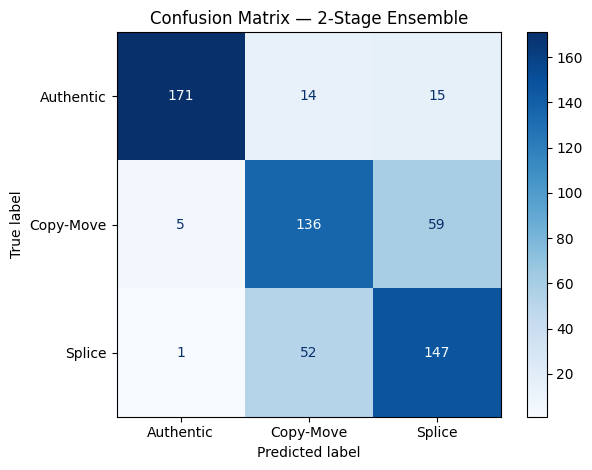

In [13]:
# ── Stage 1: authentic vs tampered ──────────────────────────────────────────
# ── Stage 2: copy-move vs splice  ────────────────────────────────────────────
# Both stages use an ensemble of GBT + RF + SVM(rbf), fitted independently.

from sklearn.calibration import CalibratedClassifierCV


def make_ensemble(n_estimators=400, random_state=42):
    gbt = GradientBoostingClassifier(
        n_estimators=n_estimators, learning_rate=0.04,
        max_depth=3, subsample=0.8,
        min_samples_leaf=4, random_state=random_state)
    rf  = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=None,
        min_samples_leaf=2, class_weight='balanced_subsample',
        n_jobs=-1, random_state=random_state)
    svm = CalibratedClassifierCV(
        SVC(kernel='rbf', C=8, gamma='scale', class_weight='balanced', probability=False),
        cv=3)
    pipe_gbt = Pipeline([('sc', StandardScaler()), ('clf', gbt)])
    pipe_rf  = Pipeline([('sc', StandardScaler()), ('clf', rf)])
    pipe_svm = Pipeline([('sc', StandardScaler()), ('clf', svm)])
    ensemble = VotingClassifier(
        estimators=[('gbt', pipe_gbt), ('rf', pipe_rf), ('svm', pipe_svm)],
        voting='soft', weights=[3, 4, 3], n_jobs=1)
    return ensemble


# ── Split data ───────────────────────────────────────────────────────────────
X = np.array(X_all, dtype=np.float32)
y = np.array(y_all, dtype=np.int32)
paths = np.array(paths_all, dtype=object)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

X_tr, X_te, y_tr, y_te, paths_tr, paths_te = train_test_split(
    X, y, paths, test_size=0.2, stratify=y, random_state=42)

# ── Stage 1 training (0=authentic vs 1=tampered) ─────────────────────────────
y_tr_s1 = (y_tr > 0).astype(int)
y_te_s1 = (y_te > 0).astype(int)

clf_s1 = make_ensemble()
clf_s1.fit(X_tr, y_tr_s1)

pred_s1_te  = clf_s1.predict(X_te)
print("=== Stage 1: Authentic vs Tampered ===")
print(classification_report(y_te_s1, pred_s1_te,
      target_names=['Authentic', 'Tampered']))

# ── Stage 2 training (1=copy-move vs 2=splice, tampered only) ────────────────
mask_tr = y_tr > 0
mask_te = y_te > 0

X_tr_s2, y_tr_s2 = X_tr[mask_tr], y_tr[mask_tr]
X_te_s2, y_te_s2 = X_te[mask_te], y_te[mask_te]
paths_te_s2 = paths_te[mask_te]

# Keep only the most discriminative stage-2 features.
# This intentionally drops weak columns that mostly add noise for small pasted regions
# and repeated textures that can look copy-move-like.
def mi_scores(X_input, y_input):
    return mutual_info_classif(X_input, y_input, random_state=42)

stage2_selector = SelectKBest(score_func=mi_scores, k=min(24, X_tr_s2.shape[1]))
X_tr_s2_sel = stage2_selector.fit_transform(X_tr_s2, y_tr_s2)
X_te_s2_sel = stage2_selector.transform(X_te_s2)

clf_s2 = make_ensemble(n_estimators=500)
clf_s2.fit(X_tr_s2_sel, y_tr_s2)

pred_s2_te  = clf_s2.predict(X_te_s2_sel)
print("\n=== Stage 2: Copy-Move vs Splice ===")
print(classification_report(y_te_s2, pred_s2_te,
      target_names=['Copy-Move', 'Splice']))

# ── Combined 3-class prediction ──────────────────────────────────────────────
def predict_3class(X_input):
    X_input = np.nan_to_num(X_input, nan=0.0, posinf=0.0, neginf=0.0)
    stage1  = clf_s1.predict(X_input)
    result  = np.zeros(len(X_input), dtype=int)
    tampered_mask = stage1 == 1
    if tampered_mask.any():
        result[tampered_mask] = clf_s2.predict(stage2_selector.transform(X_input[tampered_mask]))
    return result

y_pred_full = predict_3class(X_te)
print("\n=== Final 3-Class Report ===")
print(classification_report(y_te, y_pred_full,
      target_names=['Authentic', 'Copy-Move', 'Splice']))
print(f"Balanced accuracy: {balanced_accuracy_score(y_te, y_pred_full):.4f}")

cm = confusion_matrix(y_te, y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=['Authentic', 'Copy-Move', 'Splice'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — 2-Stage Ensemble')
plt.tight_layout()
plt.show()

predict_fn = predict_3class

In [14]:
# Inspect which feature groups matter most for Stage 2 (copy-move vs splice)
# Uses the RF sub-estimator (which exposes feature_importances_)

FEATURE_NAMES = (
    [f'akaze_{i}' for i in range(15)] +
    [f'srm_{i}'   for i in range(28)] +
    [f'selfsim_{i}' for i in range(14)] +
    [f'chroma_{i}'  for i in range(11)] +
    [f'illum_{i}'   for i in range(6)]
)
# Extract the RF pipeline from the Stage-2 VotingClassifier
rf_pipe = clf_s2.named_estimators_['rf']
rf_clf  = rf_pipe.named_steps['clf']
importances = rf_clf.feature_importances_
selected_idx = stage2_selector.get_support(indices=True)
selected_names = [FEATURE_NAMES[i] for i in selected_idx]

# Group by feature family in the original compact feature space
groups = {
    'akaze':   (0,  15),
    'srm':     (15, 43),
    'selfsim': (43, 57),
    'chroma':  (57, 68),
    'illum':   (68, 74),
}

print("Feature group importances after stage-2 selection:")
for name, (start, end) in groups.items():
    mask = (selected_idx >= start) & (selected_idx < end)
    total = importances[mask].sum() if mask.any() else 0.0
    print(f"  {name:10s}: {total:.4f}  (selected {mask.sum():2d})")

print("\nSelected stage-2 features:")
for name in selected_names:
    print(f"  {name}")

print("\nTop-10 individual selected features:")
if len(importances) > 0:
    top10_idx = np.argsort(importances)[::-1][:min(10, len(importances))]
    for idx in top10_idx:
        original_idx = int(selected_idx[idx])
        print(f"  [{original_idx:3d}] {FEATURE_NAMES[original_idx]:20s}: {importances[idx]:.4f}")

Feature group importances after stage-2 selection:
  akaze     : 0.4929  (selected 11)
  srm       : 0.2870  (selected  7)
  selfsim   : 0.0323  (selected  1)
  chroma    : 0.1482  (selected  4)
  illum     : 0.0396  (selected  1)

Selected stage-2 features:
  akaze_0
  akaze_1
  akaze_2
  akaze_3
  akaze_4
  akaze_6
  akaze_7
  akaze_8
  akaze_10
  akaze_11
  akaze_13
  srm_6
  srm_8
  srm_9
  srm_10
  srm_15
  srm_19
  srm_27
  selfsim_0
  chroma_5
  chroma_7
  chroma_8
  chroma_10
  illum_0

Top-10 individual selected features:
  [  0] akaze_0             : 0.0707
  [  8] akaze_8             : 0.0665
  [ 24] srm_9               : 0.0545
  [ 25] srm_10              : 0.0485
  [ 30] srm_15              : 0.0448
  [  2] akaze_2             : 0.0445
  [ 13] akaze_13            : 0.0440
  [ 11] akaze_11            : 0.0437
  [  1] akaze_1             : 0.0427
  [  3] akaze_3             : 0.0422


Wrongly classified samples: 146 / 600


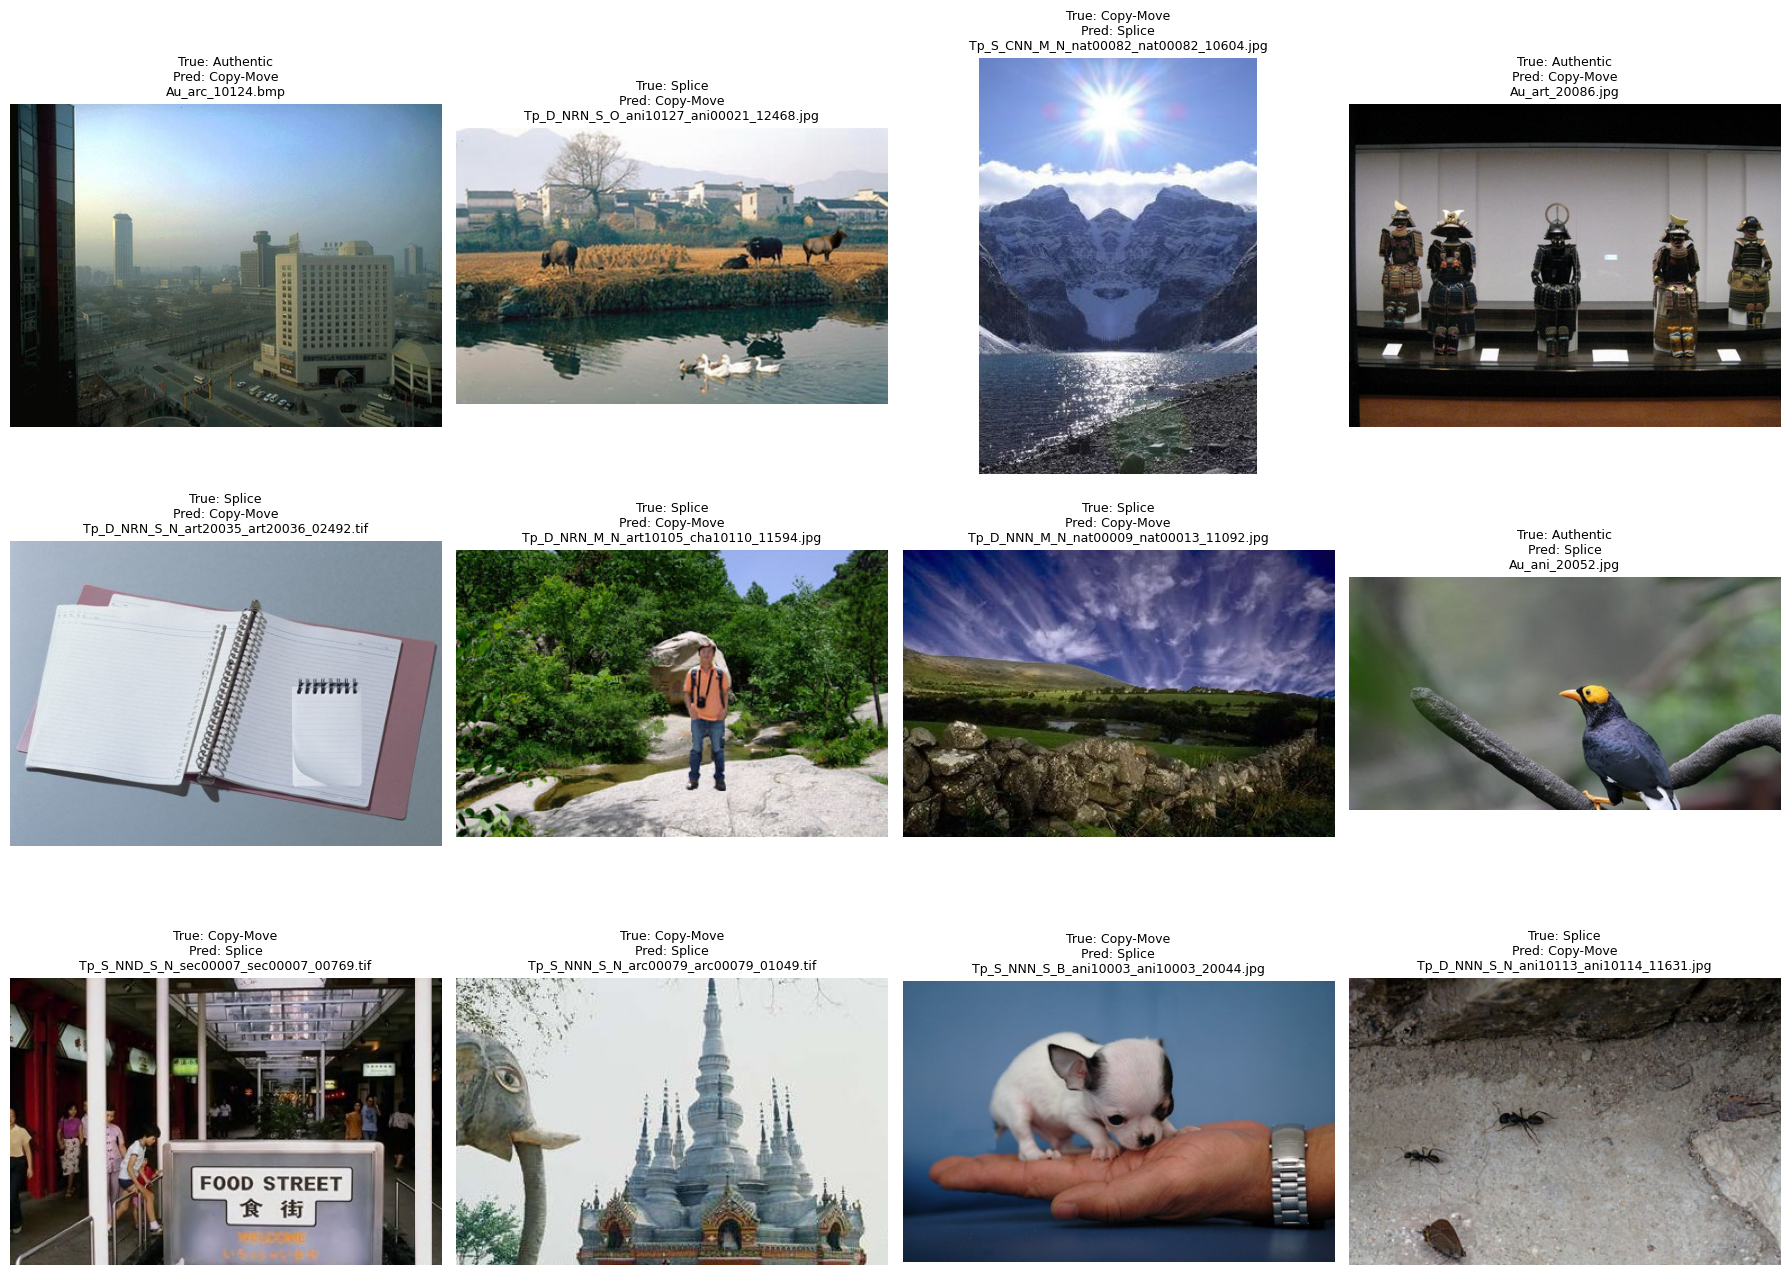

In [15]:
class_names = ['Authentic', 'Copy-Move', 'Splice']
wrong_idx = np.where(y_pred_full != y_te)[0]

print(f"Wrongly classified samples: {len(wrong_idx)} / {len(y_te)}")

if 'paths_te' in globals():
    gallery_paths_te = paths_te
else:
    full_paths = np.array(au_paths + cm_paths + sp_paths, dtype=object)
    _, _, _, _, _, gallery_paths_te = train_test_split(
        X, y, full_paths, test_size=0.2, stratify=y, random_state=42
    )

if len(wrong_idx) == 0:
    print("No misclassifications in the current test split.")
else:
    sample_idx = wrong_idx[:12]
    cols = 4
    rows = int(np.ceil(len(sample_idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, sample_idx):
        img = load_rgb(gallery_paths_te[idx])
        if img is None:
            ax.axis('off')
            continue
        ax.imshow(img)
        title_text = (
            f"True: {class_names[int(y_te[idx])] }\n"
            f"Pred: {class_names[int(y_pred_full[idx])] }\n"
            f"{gallery_paths_te[idx].name}"
        )
        ax.set_title(title_text, fontsize=9)
        ax.axis('off')

    for ax in axes[len(sample_idx):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()